In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [8]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [10]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

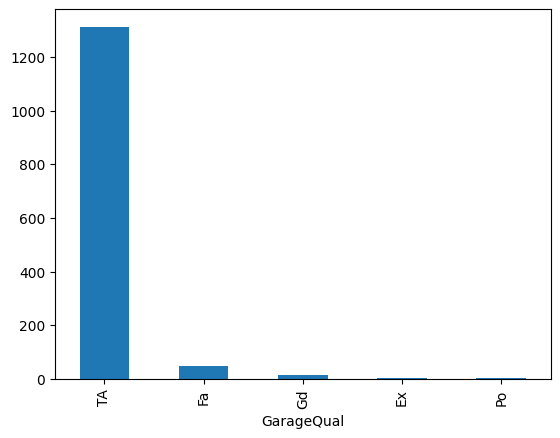

In [11]:
df['GarageQual'].value_counts().plot(kind='bar')

In [12]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'Garagequal')

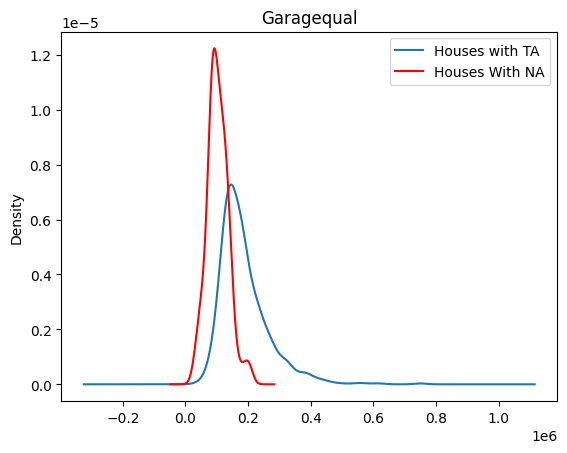

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Houses with TA','Houses With NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

In [29]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [32]:
df['GarageQual'].fillna('TA',inplace=True)

<Axes: xlabel='GarageQual'>

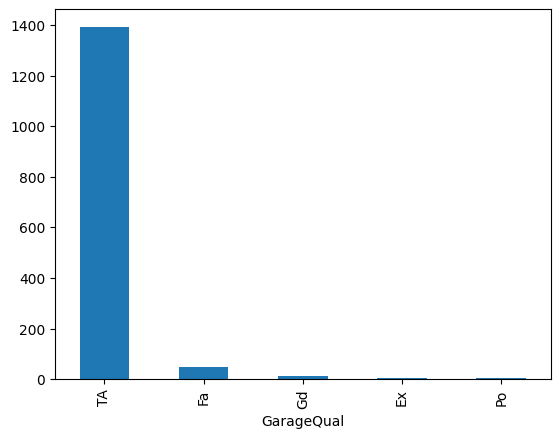

In [33]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

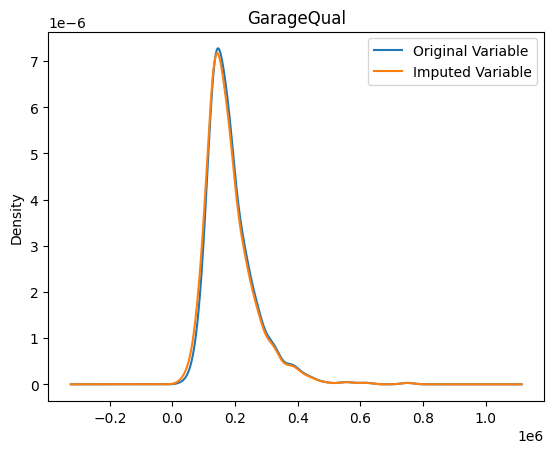

In [36]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

## Distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

lines,labels=ax.get_legend_handles_labels()
labels=['Original Variable','Imputed Variable']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

In [38]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [39]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

<Axes: xlabel='FireplaceQu'>

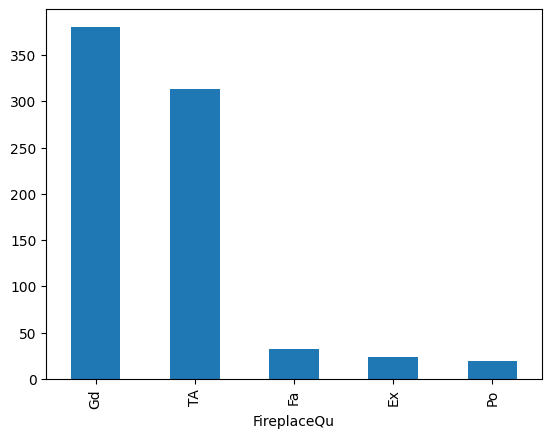

In [41]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

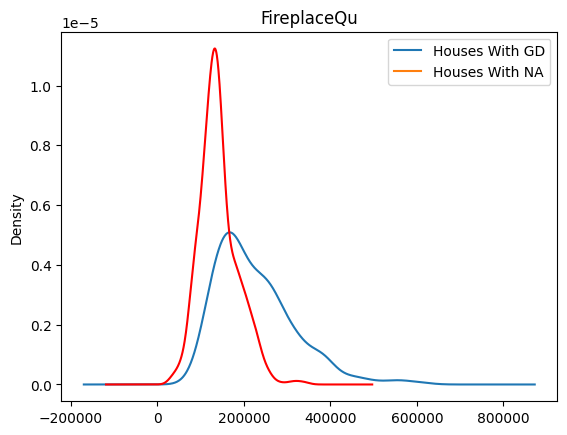

In [48]:
fig=plt.figure()
ax=fig.add_subplot()

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

line,labels=ax.get_legend_handles_labels()
labels=['Houses With GD','Houses With NA']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')

In [49]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [50]:
df['FireplaceQu'].fillna('Gd', inplace=True)

C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_6020\3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

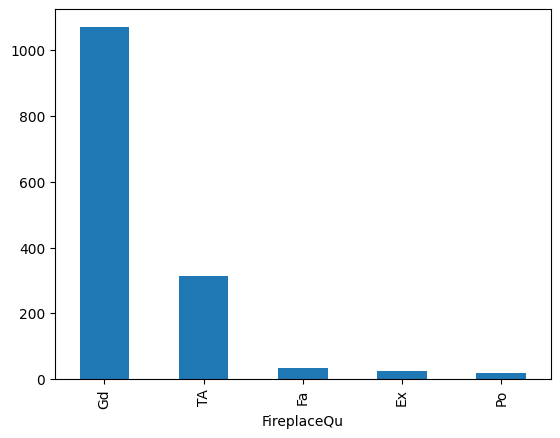

In [51]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

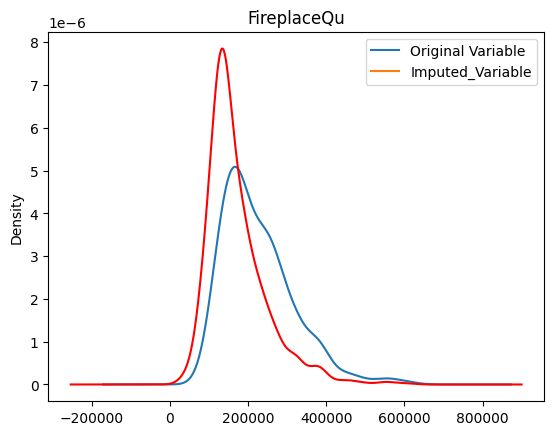

In [54]:
fig=plt.figure()
ax=fig.add_subplot()

temp.plot(kind='kde',ax=ax)

## distribution of variable after imputation
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

line,labels=ax.get_legend_handles_labels()
labels=['Original Variable','Imputed_Variable']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')

In [56]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['SalePrice'])
y=df['SalePrice']
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [57]:
from sklearn.impute import SimpleImputer

In [60]:
imputer=SimpleImputer(strategy='most_frequent')

In [61]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.fit_transform(x_test)

In [62]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)